# Thesis — Change Detection on LEVIR-CD
# Ahmed Adel — 2026

# Chapter 1 — Setup
## Mount drive, install libraries, imports, seed, device


---




In [2]:
# Connect Google Drive so I can access the dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Install the segmentation library (only needed once per session)
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.2 MB/s eta 0:00:00


In [4]:
# All imports in one place
import os, random, numpy as np
import torch, torch.nn as nn
import segmentation_models_pytorch as smp
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

In [21]:
# Fix random seed for reproducibility (fair comparison)
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Use GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


# Chapter 2 — Dataset
## Load LEVIR-CD directly from Google Drive (no copying needed)

---



In [5]:
# Point directly to Drive
BASE = '/content/drive/MyDrive/dataset(levir-cd)/LEVIR CD'

# Verify the three splits exist
print('Splits found:', os.listdir(BASE))

# Count images in each folder
for split in ['train', 'val', 'test']:
    for folder in ['A', 'B', 'label']:
        path = f'{BASE}/{split}/{folder}'
        count = len(os.listdir(path))
        print(f'  {split}/{folder}: {count} images')

Splits found: ['train', 'val', 'test']
  train/A: 445 images
  train/B: 445 images
  train/label: 445 images
  val/A: 64 images
  val/B: 64 images
  val/label: 64 images
  test/A: 128 images
  test/B: 128 images
  test/label: 128 images


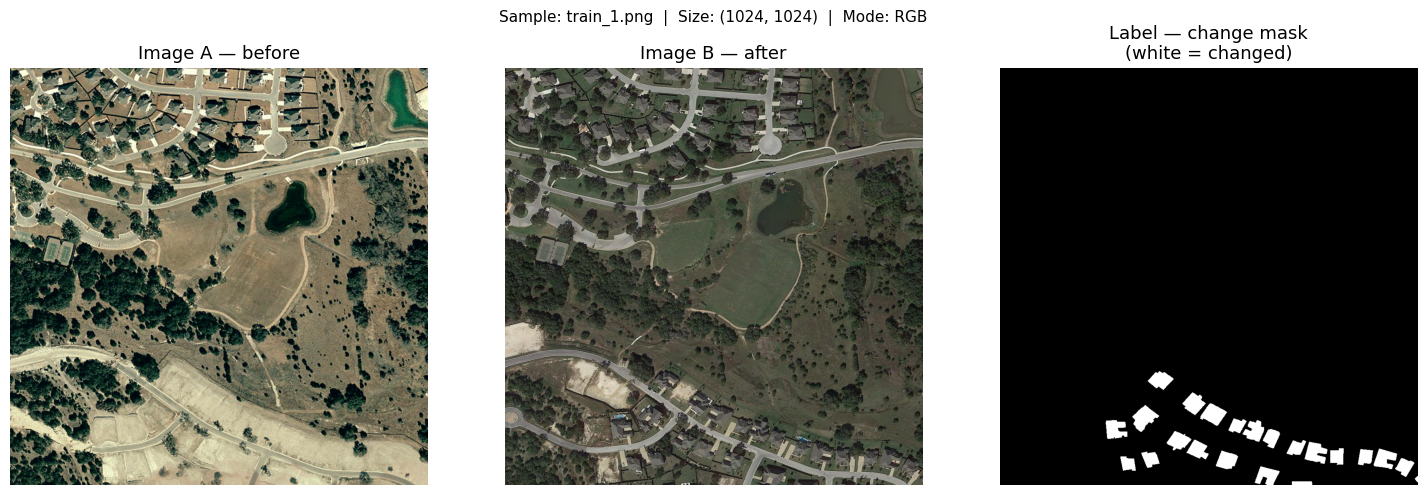

Image size: (1024, 1024)
Image mode: RGB
Label mode: L


In [ ]:
# Open and display one single triplet so we understand exactly what we are working with
img_name = sorted(os.listdir(f'{BASE}/train/A'))[0]

img_A     = Image.open(f'{BASE}/train/A/{img_name}')
img_B     = Image.open(f'{BASE}/train/B/{img_name}')
img_label = Image.open(f'{BASE}/train/label/{img_name}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_A)
axes[0].set_title('Image A — before', fontsize=13)
axes[0].axis('off')

axes[1].imshow(img_B)
axes[1].set_title('Image B — after', fontsize=13)
axes[1].axis('off')

axes[2].imshow(img_label, cmap='gray')
axes[2].set_title('Label — change mask\n(white = changed)', fontsize=13)
axes[2].axis('off')

plt.suptitle(f'Sample: {img_name}  |  Size: {img_A.size}  |  Mode: {img_A.mode}', fontsize=11)
plt.tight_layout()
plt.show()

print(f'Image size: {img_A.size}')
print(f'Image mode: {img_A.mode}')
print(f'Label mode: {img_label.mode}')

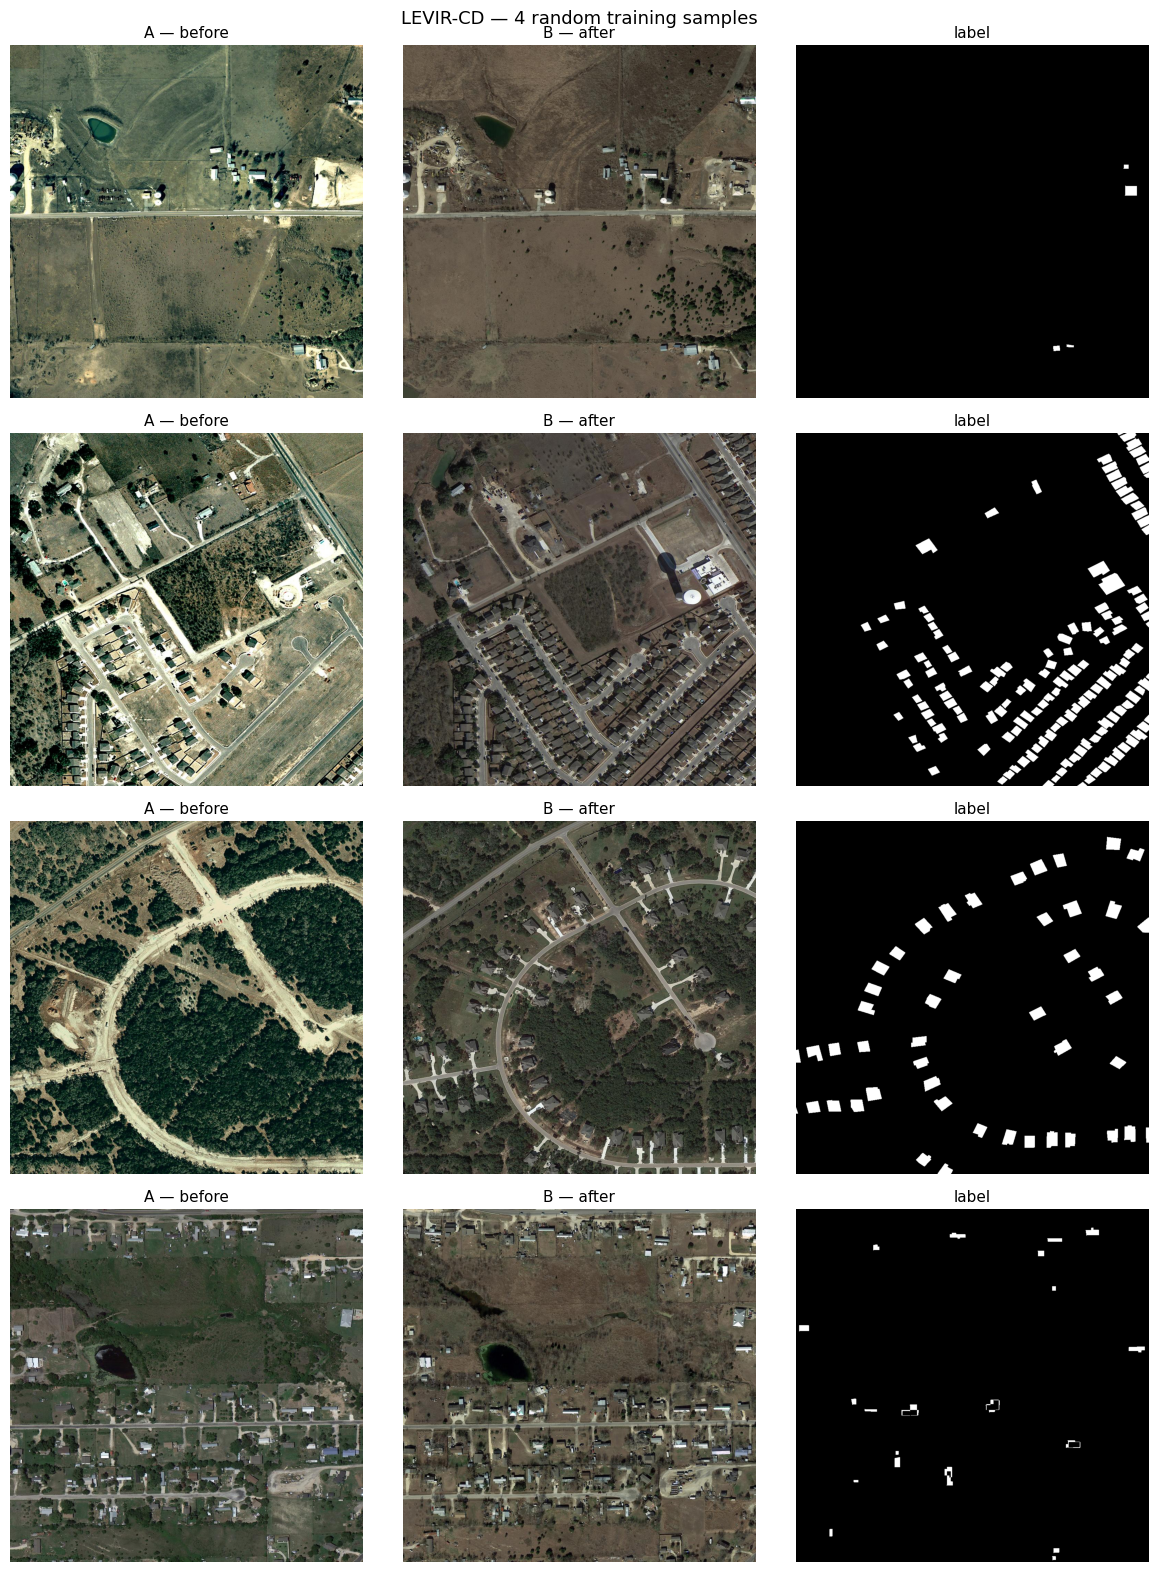

In [ ]:
# Display 4 random pairs to get a feel for dataset variety
random.seed(42)
samples = random.sample(sorted(os.listdir(f'{BASE}/train/A')), 4)

fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for i, img_name in enumerate(samples):
    img_A     = Image.open(f'{BASE}/train/A/{img_name}')
    img_B     = Image.open(f'{BASE}/train/B/{img_name}')
    img_label = Image.open(f'{BASE}/train/label/{img_name}')

    axes[i, 0].imshow(img_A)
    axes[i, 0].set_title('A — before', fontsize=11)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(img_B)
    axes[i, 1].set_title('B — after', fontsize=11)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(img_label, cmap='gray')
    axes[i, 2].set_title('label', fontsize=11)
    axes[i, 2].axis('off')

    # Add filename on the left
    axes[i, 0].set_ylabel(img_name, fontsize=9, rotation=0, labelpad=80, va='center')

plt.suptitle('LEVIR-CD — 4 random training samples', fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
# Computing class imbalance across the FULL training set
# This loops through all 445 label images and counts pixels

total_pixels   = 0
changed_pixels = 0

for img_name in sorted(os.listdir(f'{BASE}/train/label')):
    label          = np.array(Image.open(f'{BASE}/train/label/{img_name}'))
    total_pixels   += label.size
    changed_pixels += (label > 0).sum()

unchanged_pixels = total_pixels - changed_pixels
pct_changed      = (changed_pixels / total_pixels) * 100
pct_unchanged    = 100 - pct_changed
imbalance_ratio  = int(unchanged_pixels / changed_pixels)

print('=' * 45)
print('LEVIR-CD Training Set Statistics')
print('=' * 45)
print(f'Total images:       445 pairs')
print(f'Image size:         1024 x 1024 pixels')
print(f'Total pixels:       {total_pixels:,}')
print(f'Changed pixels:     {changed_pixels:,} ({pct_changed:.2f}%)')
print(f'Unchanged pixels:   {unchanged_pixels:,} ({pct_unchanged:.2f}%)')
print(f'Imbalance ratio:    1 : {imbalance_ratio}')
print('=' * 45)
print('Key insight: a model predicting no change')
print(f'everywhere would score {pct_unchanged:.1f}% accuracy')
print('but F1 = 0.0 — this is why we use F1 and IoU')

LEVIR-CD Training Set Statistics
Total images:       445 pairs
Image size:         1024 x 1024 pixels
Total pixels:       466,616,320
Changed pixels:     21,412,971 (4.59%)
Unchanged pixels:   445,203,349 (95.41%)
Imbalance ratio:    1 : 20
Key insight: a model predicting no change
everywhere would score 95.4% accuracy
but F1 = 0.0 — this is why we use F1 and IoU


In [7]:
# Verify imbalance is consistent across train, val, test
# Important for thesis — confirms the dataset was split fairly

print(f'{"Split":>8} | {"Images":>8} | {"Changed%":>10} | {"Ratio":>8}')
print('-' * 42)

for split in ['train', 'val', 'test']:
    total   = 0
    changed = 0
    n_imgs  = len(os.listdir(f'{BASE}/{split}/label'))

    for img_name in os.listdir(f'{BASE}/{split}/label'):
        label    = np.array(Image.open(f'{BASE}/{split}/label/{img_name}'))
        total   += label.size
        changed += (label > 0).sum()

    pct   = (changed / total) * 100
    ratio = int((total - changed) / changed)
    print(f'{split:>8} | {n_imgs:>8} | {pct:>9.2f}% | 1:{ratio:>5}')

   Split |   Images |   Changed% |    Ratio
------------------------------------------
   train |      445 |      4.59% | 1:   20
     val |       64 |      4.20% | 1:   22
    test |      128 |      5.09% | 1:   18


In [8]:
# Dataset class — loads one triplet (A, B, label) per call
# img_size=256 because we resize from 1024 to save GPU memory

class LEVIRDataset(Dataset):
    def __init__(self, base_path, split, img_size=256):
        self.base      = f'{base_path}/{split}'
        self.img_size  = img_size
        self.images    = sorted(os.listdir(f'{self.base}/A'))

        # Pipeline applied to every image automatically
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),            # converts PIL image to tensor, scales 0-255 to 0.0-1.0
        ])

    def __len__(self):
        # PyTorch calls this to know how many samples exist
        return len(self.images)

    def __getitem__(self, idx):
        # PyTorch calls this with an index to get one sample
        name = self.images[idx]

        # Load and transform image A and B
        A = self.transform(Image.open(f'{self.base}/A/{name}').convert('RGB'))
        B = self.transform(Image.open(f'{self.base}/B/{name}').convert('RGB'))

        # Load label — greyscale only, then convert to binary 0/1
        label = Image.open(f'{self.base}/label/{name}').convert('L')
        label = transforms.Resize((self.img_size, self.img_size))(label)
        label = torch.tensor(np.array(label) > 0, dtype=torch.float32)

        return A, B, label

In [9]:
# Create three DataLoaders — one per split
train_dataset = LEVIRDataset(BASE, 'train')
val_dataset   = LEVIRDataset(BASE, 'val')
test_dataset  = LEVIRDataset(BASE, 'test')

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False, num_workers=2)

# Verify one batch loads correctly
A, B, label = next(iter(train_loader))

print('DataLoaders created successfully')
print(f'Train batches:      {len(train_loader)}')
print(f'Val batches:        {len(val_loader)}')
print(f'Test batches:       {len(test_loader)}')
print()
print(f'A shape:            {A.shape}     (batch, channels, height, width)')
print(f'B shape:            {B.shape}')
print(f'Label shape:        {label.shape}  (batch, height, width)')
print(f'A value range:      {A.min():.2f} to {A.max():.2f}')
print(f'Label unique vals:  {label.unique()}  (0=unchanged, 1=changed)')

DataLoaders created successfully
Train batches:      56
Val batches:        8
Test batches:       16

A shape:            torch.Size([8, 3, 256, 256])     (batch, channels, height, width)
B shape:            torch.Size([8, 3, 256, 256])
Label shape:        torch.Size([8, 256, 256])  (batch, height, width)
A value range:      0.00 to 1.00
Label unique vals:  tensor([0., 1.])  (0=unchanged, 1=changed)


# Chapter 3 — Model 1: FC-EF Baseline
## Early fusion UNet — 6 input channels
## Minimum baseline — literature reports F1 ≈ 0.77 on LEVIR-CD

---



In [15]:
# FC-EF — 100% original architecture from Daudt et al. 2018
# Source: github.com/rcdaudt/fully_convolutional_change_detection
# Zero modifications to architecture, activation, or output format

import torch.nn.functional as F
from torch.nn.modules.padding import ReplicationPad2d

class FCEF(nn.Module):

    def __init__(self, input_nbr=6, label_nbr=2):
        super(FCEF, self).__init__()

        self.input_nbr = input_nbr

        # ENCODER — Stage 1
        self.conv11 = nn.Conv2d(input_nbr, 16, kernel_size=3, padding=1)
        self.bn11   = nn.BatchNorm2d(16)
        self.do11   = nn.Dropout2d(p=0.2)
        self.conv12 = nn.Conv2d(16, 16, kernel_size=3, padding=1)
        self.bn12   = nn.BatchNorm2d(16)
        self.do12   = nn.Dropout2d(p=0.2)

        # ENCODER — Stage 2
        self.conv21 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn21   = nn.BatchNorm2d(32)
        self.do21   = nn.Dropout2d(p=0.2)
        self.conv22 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn22   = nn.BatchNorm2d(32)
        self.do22   = nn.Dropout2d(p=0.2)

        # ENCODER — Stage 3
        self.conv31 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn31   = nn.BatchNorm2d(64)
        self.do31   = nn.Dropout2d(p=0.2)
        self.conv32 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn32   = nn.BatchNorm2d(64)
        self.do32   = nn.Dropout2d(p=0.2)
        self.conv33 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn33   = nn.BatchNorm2d(64)
        self.do33   = nn.Dropout2d(p=0.2)

        # ENCODER — Stage 4
        self.conv41 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn41   = nn.BatchNorm2d(128)
        self.do41   = nn.Dropout2d(p=0.2)
        self.conv42 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn42   = nn.BatchNorm2d(128)
        self.do42   = nn.Dropout2d(p=0.2)
        self.conv43 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn43   = nn.BatchNorm2d(128)
        self.do43   = nn.Dropout2d(p=0.2)

        # DECODER — Stage 4d
        self.upconv4 = nn.ConvTranspose2d(128, 128, kernel_size=3, padding=1, stride=2, output_padding=1)
        self.conv43d = nn.ConvTranspose2d(256, 128, kernel_size=3, padding=1)
        self.bn43d   = nn.BatchNorm2d(128)
        self.do43d   = nn.Dropout2d(p=0.2)
        self.conv42d = nn.ConvTranspose2d(128, 128, kernel_size=3, padding=1)
        self.bn42d   = nn.BatchNorm2d(128)
        self.do42d   = nn.Dropout2d(p=0.2)
        self.conv41d = nn.ConvTranspose2d(128, 64, kernel_size=3, padding=1)
        self.bn41d   = nn.BatchNorm2d(64)
        self.do41d   = nn.Dropout2d(p=0.2)

        # DECODER — Stage 3d
        self.upconv3 = nn.ConvTranspose2d(64, 64, kernel_size=3, padding=1, stride=2, output_padding=1)
        self.conv33d = nn.ConvTranspose2d(128, 64, kernel_size=3, padding=1)
        self.bn33d   = nn.BatchNorm2d(64)
        self.do33d   = nn.Dropout2d(p=0.2)
        self.conv32d = nn.ConvTranspose2d(64, 64, kernel_size=3, padding=1)
        self.bn32d   = nn.BatchNorm2d(64)
        self.do32d   = nn.Dropout2d(p=0.2)
        self.conv31d = nn.ConvTranspose2d(64, 32, kernel_size=3, padding=1)
        self.bn31d   = nn.BatchNorm2d(32)
        self.do31d   = nn.Dropout2d(p=0.2)

        # DECODER — Stage 2d
        self.upconv2 = nn.ConvTranspose2d(32, 32, kernel_size=3, padding=1, stride=2, output_padding=1)
        self.conv22d = nn.ConvTranspose2d(64, 32, kernel_size=3, padding=1)
        self.bn22d   = nn.BatchNorm2d(32)
        self.do22d   = nn.Dropout2d(p=0.2)
        self.conv21d = nn.ConvTranspose2d(32, 16, kernel_size=3, padding=1)
        self.bn21d   = nn.BatchNorm2d(16)
        self.do21d   = nn.Dropout2d(p=0.2)

        # DECODER — Stage 1d
        self.upconv1 = nn.ConvTranspose2d(16, 16, kernel_size=3, padding=1, stride=2, output_padding=1)
        self.conv12d = nn.ConvTranspose2d(32, 16, kernel_size=3, padding=1)
        self.bn12d   = nn.BatchNorm2d(16)
        self.do12d   = nn.Dropout2d(p=0.2)

        # Final layer — original: outputs label_nbr=2 channels
        self.conv11d = nn.ConvTranspose2d(16, label_nbr, kernel_size=3, padding=1)

        # Original activation — LogSoftmax over channel dimension
        self.sm = nn.LogSoftmax(dim=1)

    def forward(self, x1, x2):
        # Original forward — receives A and B separately
        # concatenates them internally — this IS the early fusion
        x = torch.cat((x1, x2), 1)

        # ENCODER
        x11 = self.do11(F.relu(self.bn11(self.conv11(x))))
        x12 = self.do12(F.relu(self.bn12(self.conv12(x11))))
        x1p = F.max_pool2d(x12, kernel_size=2, stride=2)

        x21 = self.do21(F.relu(self.bn21(self.conv21(x1p))))
        x22 = self.do22(F.relu(self.bn22(self.conv22(x21))))
        x2p = F.max_pool2d(x22, kernel_size=2, stride=2)

        x31 = self.do31(F.relu(self.bn31(self.conv31(x2p))))
        x32 = self.do32(F.relu(self.bn32(self.conv32(x31))))
        x33 = self.do33(F.relu(self.bn33(self.conv33(x32))))
        x3p = F.max_pool2d(x33, kernel_size=2, stride=2)

        x41 = self.do41(F.relu(self.bn41(self.conv41(x3p))))
        x42 = self.do42(F.relu(self.bn42(self.conv42(x41))))
        x43 = self.do43(F.relu(self.bn43(self.conv43(x42))))
        x4p = F.max_pool2d(x43, kernel_size=2, stride=2)

        # DECODER
        x4d  = self.upconv4(x4p)
        pad4 = ReplicationPad2d((0, x43.size(3) - x4d.size(3), 0, x43.size(2) - x4d.size(2)))
        x4d  = torch.cat((pad4(x4d), x43), 1)
        x43d = self.do43d(F.relu(self.bn43d(self.conv43d(x4d))))
        x42d = self.do42d(F.relu(self.bn42d(self.conv42d(x43d))))
        x41d = self.do41d(F.relu(self.bn41d(self.conv41d(x42d))))

        x3d  = self.upconv3(x41d)
        pad3 = ReplicationPad2d((0, x33.size(3) - x3d.size(3), 0, x33.size(2) - x3d.size(2)))
        x3d  = torch.cat((pad3(x3d), x33), 1)
        x33d = self.do33d(F.relu(self.bn33d(self.conv33d(x3d))))
        x32d = self.do32d(F.relu(self.bn32d(self.conv32d(x33d))))
        x31d = self.do31d(F.relu(self.bn31d(self.conv31d(x32d))))

        x2d  = self.upconv2(x31d)
        pad2 = ReplicationPad2d((0, x22.size(3) - x2d.size(3), 0, x22.size(2) - x2d.size(2)))
        x2d  = torch.cat((pad2(x2d), x22), 1)
        x22d = self.do22d(F.relu(self.bn22d(self.conv22d(x2d))))
        x21d = self.do21d(F.relu(self.bn21d(self.conv21d(x22d))))

        x1d  = self.upconv1(x21d)
        pad1 = ReplicationPad2d((0, x12.size(3) - x1d.size(3), 0, x12.size(2) - x1d.size(2)))
        x1d  = torch.cat((pad1(x1d), x12), 1)
        x12d = self.do12d(F.relu(self.bn12d(self.conv12d(x1d))))
        x11d = self.conv11d(x12d)

        # Original activation — LogSoftmax
        return self.sm(x11d)


# Build model
torch.manual_seed(42)
model = FCEF(input_nbr=6, label_nbr=2).to(device)

total_params = sum(p.numel() for p in model.parameters())
print('FC-EF — 100% original Daudt et al. 2018 architecture')
print(f'Output: 2 channels with LogSoftmax — original format')
print(f'Total parameters: {total_params:,}')
print(f'Running on: {device}')

FC-EF — 100% original Daudt et al. 2018 architecture
Output: 2 channels with LogSoftmax — original format
Total parameters: 1,350,578
Running on: cpu


In [16]:
# Compute weights dynamically from actual training set statistics
# No hardcoding — works correctly for any dataset

total_pixels   = 0
changed_pixels = 0

for img_name in sorted(os.listdir(f'{BASE}/train/label')):
    label          = np.array(Image.open(f'{BASE}/train/label/{img_name}'))
    total_pixels   += label.size
    changed_pixels += (label > 0).sum()

unchanged_pixels = total_pixels - changed_pixels

# Inverse weighting — rare class gets higher weight
weight_unchanged = 2 * changed_pixels / total_pixels
weight_changed   = 2 * unchanged_pixels / total_pixels

weights   = torch.FloatTensor([weight_unchanged, weight_changed]).to(device)
criterion = nn.NLLLoss(weight=weights)
optimizer = Adam(model.parameters(), lr=1e-4)

print(f'Total pixels:     {total_pixels:,}')
print(f'Changed pixels:   {changed_pixels:,} ({100*changed_pixels/total_pixels:.2f}%)')
print(f'Weight unchanged: {weight_unchanged:.4f}')
print(f'Weight changed:   {weight_changed:.4f}')
print(f'Ratio:            {weight_changed/weight_unchanged:.1f}x')
print(f'Loss:             NLLLoss with dynamic class weights')
print(f'Optimizer:        Adam  |  lr: 1e-4')

Total pixels:     466,616,320
Changed pixels:   21,412,971 (4.59%)
Weight unchanged: 0.0918
Weight changed:   1.9082
Ratio:            20.8x
Loss:             NLLLoss with dynamic class weights
Optimizer:        Adam  |  lr: 1e-4


In [17]:
# Metrics for 2-channel LogSoftmax output
def compute_metrics(preds, labels, threshold=0.5):
    # preds shape: [B, 2, H, W]
    # channel 0 = log prob of unchanged
    # channel 1 = log prob of changed

    # Convert log-probability to probability
    preds_prob   = torch.exp(preds[:, 1, :, :])

    # Apply threshold
    preds_binary = (preds_prob > threshold).float()

    # Flatten labels
    if labels.dim() == 4:
        labels = labels.squeeze(1)
    labels = labels.float()

    # Flatten both to 1D
    preds_binary = preds_binary.view(-1)
    labels       = labels.view(-1)

    # Count TP FP FN
    TP = (preds_binary * labels).sum()
    FP = (preds_binary * (1 - labels)).sum()
    FN = ((1 - preds_binary) * labels).sum()

    precision = TP / (TP + FP + 1e-8)
    recall    = TP / (TP + FN + 1e-8)
    F1        = 2 * precision * recall / (precision + recall + 1e-8)
    IoU       = TP / (TP + FP + FN + 1e-8)

    return F1.item(), IoU.item()

print('Metrics function ready')
print('Reading channel 1 (changed) from 2-channel output')
print('Converting log-probability to probability via torch.exp')

Metrics function ready
Reading channel 1 (changed) from 2-channel output
Converting log-probability to probability via torch.exp


In [18]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for A, B, label in loader:
        A     = A.to(device)
        B     = B.to(device)

        # NLLLoss expects Long integer labels not Float
        # and shape [B, H, W] not [B, 1, H, W]
        label = label.to(device).long()

        # Pass A and B separately — model does cat internally
        pred = model(A, B)  # output: [B, 2, H, W]

        # Compute loss
        loss = criterion(pred, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    total_f1   = 0
    total_iou  = 0

    with torch.no_grad():
        for A, B, label in loader:
            A     = A.to(device)
            B     = B.to(device)
            label = label.to(device).long()

            pred = model(A, B)  # [B, 2, H, W]

            loss     = criterion(pred, label)
            f1, iou  = compute_metrics(pred, label)

            total_loss += loss.item()
            total_f1   += f1
            total_iou  += iou

    n = len(loader)
    return total_loss / n, total_f1 / n, total_iou / n

print('Training loop updated — A and B passed separately')
print('Labels converted to Long for NLLLoss')

Training loop updated — A and B passed separately
Labels converted to Long for NLLLoss


In [ ]:
# Train FC-EF for 50 epochs
# This will take approximately 20-40 minutes on a GPU
# Do not close the browser while it runs

NUM_EPOCHS      = 50
SAVE_EVERY      = 5
CHECKPOINT_PATH = '/content/drive/MyDrive/fcef_checkpoint.pth'

# PROTECTION 2 — auto resume from checkpoint if it exists
start_epoch = 1
history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_iou': []}

if os.path.exists(CHECKPOINT_PATH):
    print('Checkpoint found — loading...')
    checkpoint = torch.load(CHECKPOINT_PATH)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    history     = checkpoint['history']
    start_epoch = checkpoint['epoch'] + 1
    print(f'Resuming from epoch {start_epoch}')
    print(f'Best F1 so far: {max(history["val_f1"]):.4f}')
else:
    print('No checkpoint found — starting from epoch 1')

print()
print(f'Training FC-EF  |  epochs {start_epoch} to {NUM_EPOCHS}  |  device: {device}')
print()
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Val Loss":>10} | {"Val F1":>8} | {"Val IoU":>8}')
print('-' * 56)

for epoch in range(start_epoch, NUM_EPOCHS + 1):

    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_f1, val_iou = validate(
        model, val_loader, criterion, device
    )

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    history['val_iou'].append(val_iou)

    if epoch % 5 == 0 or epoch == 1:
        print(f'{epoch:>6} | {train_loss:>10.4f} | {val_loss:>10.4f} | {val_f1:>8.4f} | {val_iou:>8.4f}')

    # PROTECTION 1 — save checkpoint every 5 epochs
    if epoch % SAVE_EVERY == 0:
        torch.save({
            'epoch':                epoch,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'history':              history,
        }, CHECKPOINT_PATH)
        print(f'        ✓ saved at epoch {epoch}')

# Save final model
torch.save({
    'epoch':                NUM_EPOCHS,
    'model_state_dict':     model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history':              history,
}, CHECKPOINT_PATH)

print()
print('Training complete!')
print(f'Best Val F1:  {max(history["val_f1"]):.4f}  at epoch {history["val_f1"].index(max(history["val_f1"]))+1}')
print(f'Best Val IoU: {max(history["val_iou"]):.4f}  at epoch {history["val_iou"].index(max(history["val_iou"]))+1}')
print('Final model saved to Google Drive!')

No checkpoint found — starting from epoch 1

Training FC-EF  |  epochs 1 to 50  |  device: cuda

 Epoch | Train Loss |   Val Loss |   Val F1 |  Val IoU
--------------------------------------------------------
     1 |     0.9008 |     0.7074 |   0.1681 |   0.0930
     5 |     0.6220 |     0.4648 |   0.3408 |   0.2084
        ✓ saved at epoch 5
    10 |     0.4855 |     0.4213 |   0.4537 |   0.2975
        ✓ saved at epoch 10
    15 |     0.4057 |     0.4110 |   0.5468 |   0.3787
        ✓ saved at epoch 15
    20 |     0.3827 |     0.3515 |   0.5563 |   0.3888
        ✓ saved at epoch 20
    25 |     0.3709 |     0.2759 |   0.5336 |   0.3676
        ✓ saved at epoch 25
    30 |     0.3376 |     0.2803 |   0.5707 |   0.4032
        ✓ saved at epoch 30
    35 |     0.3263 |     0.2460 |   0.5464 |   0.3795
        ✓ saved at epoch 35
    40 |     0.3068 |     0.2504 |   0.5769 |   0.4092
        ✓ saved at epoch 40
    45 |     0.2930 |     0.2648 |   0.6026 |   0.4353
        ✓ saved at

In [ ]:
# Load best checkpoint (epoch 44) and evaluate on test set
checkpoint = torch.load('/content/drive/MyDrive/fcef_checkpoint.pth')
model.load_state_dict(checkpoint['model_state_dict'])

test_loss, test_f1, test_iou = validate(
    model, test_loader, criterion, device
)

print('=' * 40)
print('FC-EF — Final Test Set Results')
print('=' * 40)
print(f'Test F1:   {test_f1:.4f}')
print(f'Test IoU:  {test_iou:.4f}')
print(f'Test Loss: {test_loss:.4f}')
print('=' * 40)
print(f'Best Val F1 (epoch 44): 0.6121')
print(f'Literature F1:          ~0.77')

FC-EF — Final Test Set Results
Test F1:   0.5557
Test IoU:  0.3964
Test Loss: 0.2148
Best Val F1 (epoch 44): 0.6121
Literature F1:          ~0.77


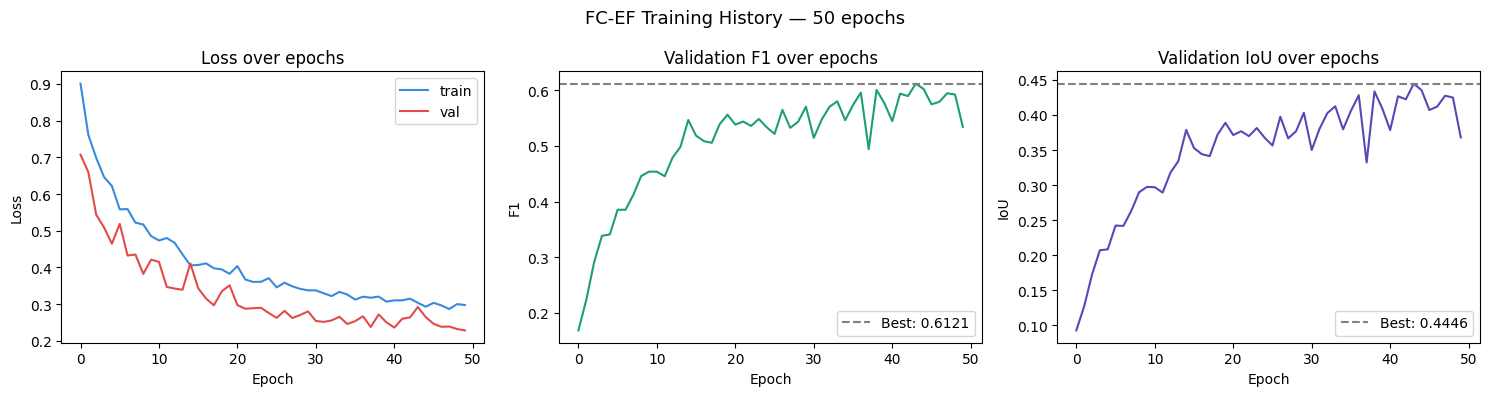

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='train', color='#378ADD')
axes[0].plot(history['val_loss'],   label='val',   color='#E24B4A')
axes[0].set_title('Loss over epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history['val_f1'], color='#1D9E75')
axes[1].set_title('Validation F1 over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].axhline(y=max(history['val_f1']), color='gray',
                linestyle='--', label=f'Best: {max(history["val_f1"]):.4f}')
axes[1].legend()

axes[2].plot(history['val_iou'], color='#534AB7')
axes[2].set_title('Validation IoU over epochs')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('IoU')
axes[2].axhline(y=max(history['val_iou']), color='gray',
                linestyle='--', label=f'Best: {max(history["val_iou"]):.4f}')
axes[2].legend()

plt.suptitle('FC-EF Training History — 50 epochs', fontsize=13)
plt.tight_layout()
plt.show()

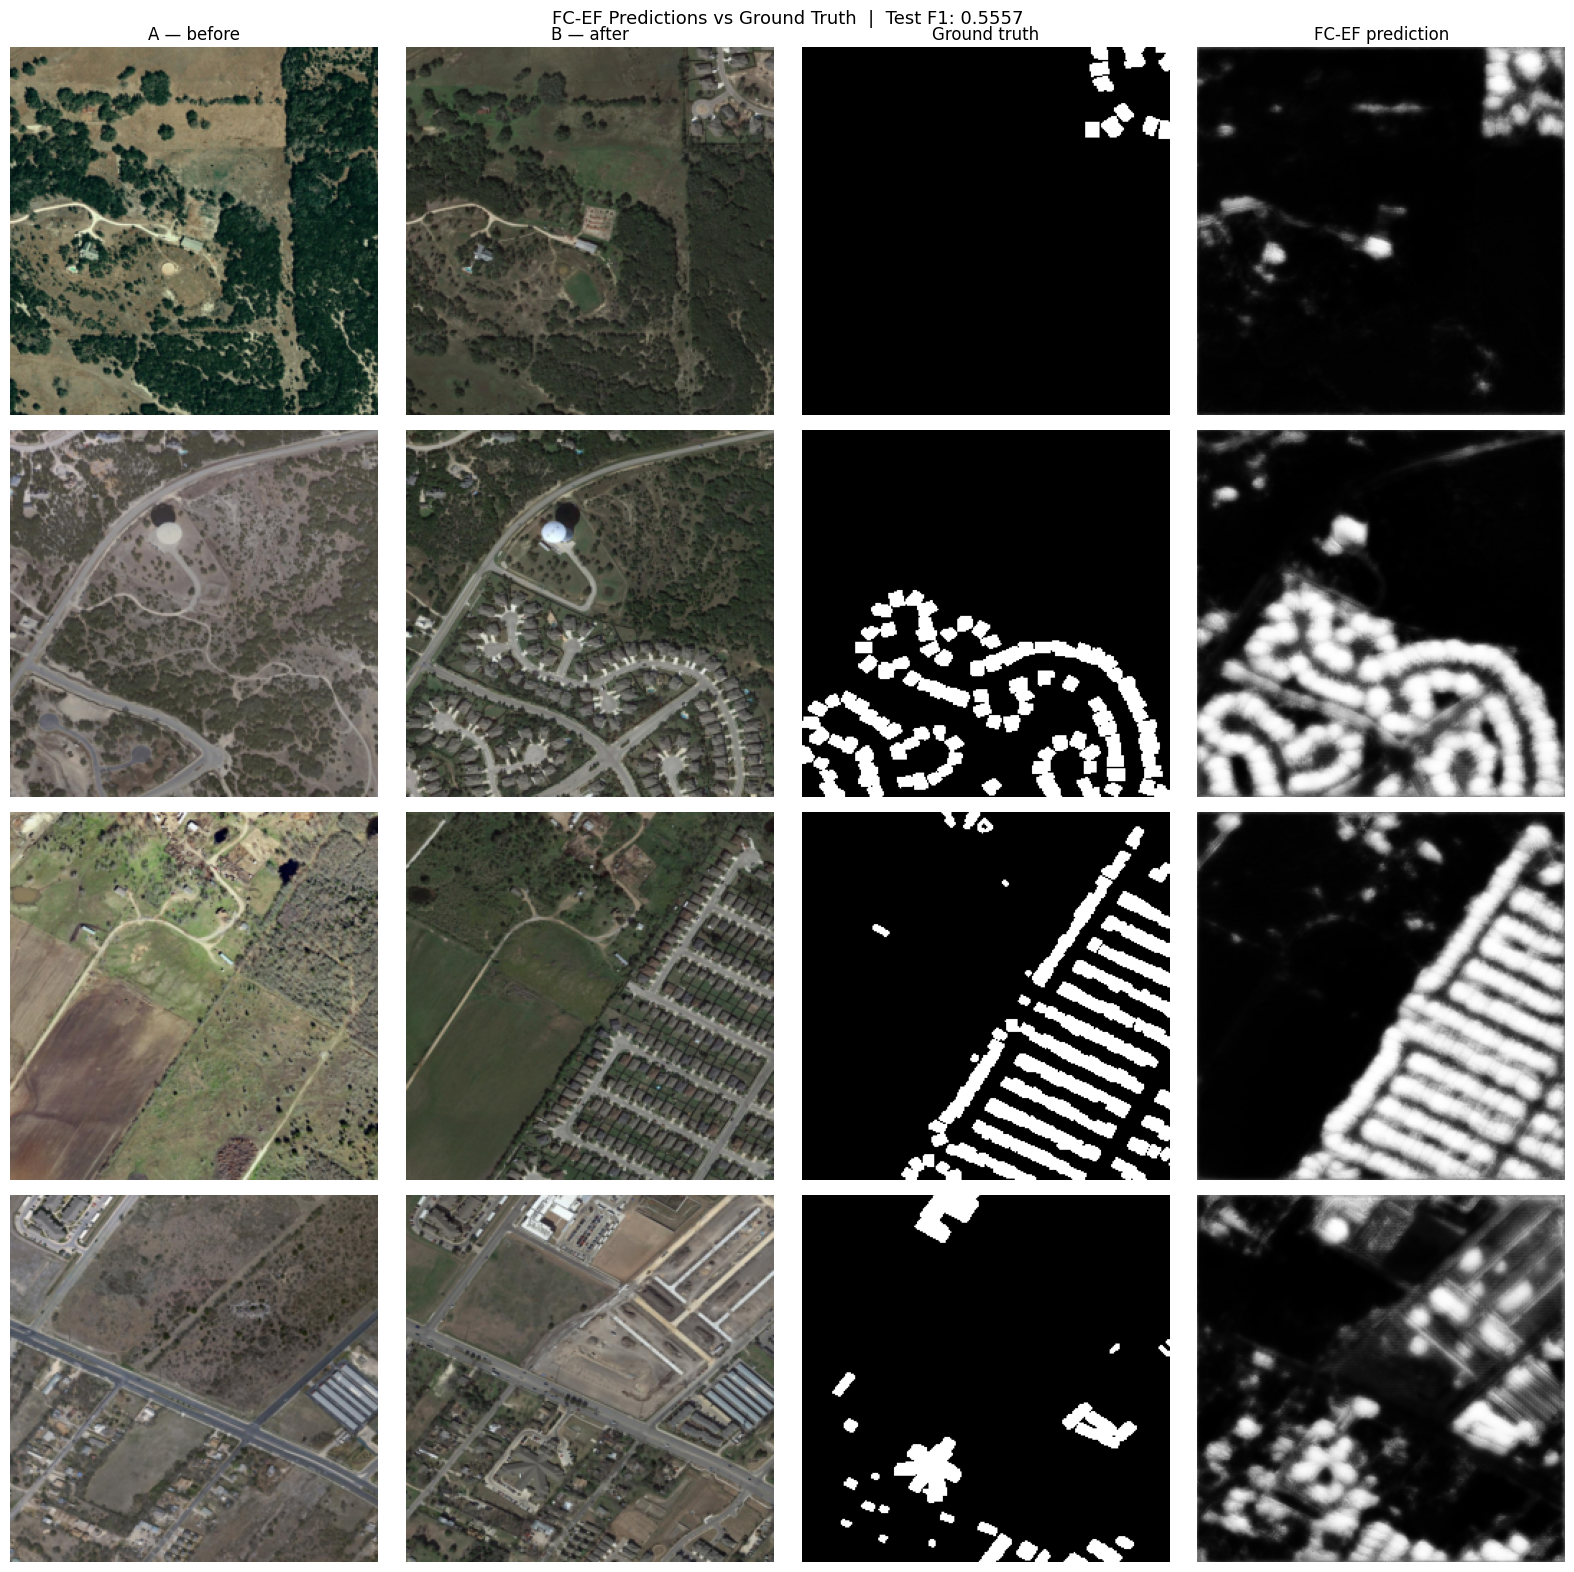

In [ ]:
# Visualise FC-EF predictions on test set
model.eval()
A_batch, B_batch, label_batch = next(iter(test_loader))
A_batch = A_batch.to(device)
B_batch = B_batch.to(device)

with torch.no_grad():
    pred = model(A_batch, B_batch)  # [B, 2, H, W]
    pred_prob = torch.exp(pred[:, 1, :, :])  # changed probability

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
col_titles = ['A — before', 'B — after', 'Ground truth', 'FC-EF prediction']

for i in range(4):
    img_A = A_batch[i].cpu().permute(1, 2, 0).numpy()
    img_B = B_batch[i].cpu().permute(1, 2, 0).numpy()
    gt    = label_batch[i].numpy()
    pr    = pred_prob[i].cpu().numpy()

    axes[i][0].imshow(img_A)
    axes[i][1].imshow(img_B)
    axes[i][2].imshow(gt, cmap='gray')
    axes[i][3].imshow(pr, cmap='gray')

    for j in range(4):
        axes[i][j].axis('off')
        if i == 0:
            axes[i][j].set_title(col_titles[j], fontsize=12)

plt.suptitle(f'FC-EF Predictions vs Ground Truth  |  Test F1: 0.5557', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ─────────────────────────────────────────────
# Chapter 4 — Resolution Experiments
# Train FC-EF at 3 different input resolutions
# and compare F1 / IoU on the test set
# ─────────────────────────────────────────────

def run_resolution_experiment(img_size, num_epochs=50):

    print(f"\n{'='*55}")
    print(f"  EXPERIMENT: img_size = {img_size}x{img_size}")
    print(f"{'='*55}\n")

    # ── 1. Datasets at this resolution ──────────────────────
    train_ds = LEVIRDataset(BASE, 'train', img_size=img_size)
    val_ds   = LEVIRDataset(BASE, 'val',   img_size=img_size)
    test_ds  = LEVIRDataset(BASE, 'test',  img_size=img_size)

    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2)
    val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2)
    test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, num_workers=2)

    # ── 2. Fresh model — always from scratch ────────────────
    torch.manual_seed(42)
    model_exp = FCEF(input_nbr=6, label_nbr=2).to(device)
    optimizer_exp = Adam(model_exp.parameters(), lr=1e-4)

    # ── 3. Separate checkpoint per resolution ───────────────
    # Each resolution saves to its own file — no conflicts
    ckpt_path = f'/content/drive/MyDrive/fcef_{img_size}.pth'

    history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_iou': []}
    start_epoch = 1

    if os.path.exists(ckpt_path):
        print(f'Checkpoint found for {img_size}x{img_size} — resuming...')
        ckpt = torch.load(ckpt_path)
        model_exp.load_state_dict(ckpt['model_state_dict'])
        optimizer_exp.load_state_dict(ckpt['optimizer_state_dict'])
        history     = ckpt['history']
        start_epoch = ckpt['epoch'] + 1
        print(f'Resuming from epoch {start_epoch}')
    else:
        print(f'No checkpoint found — starting from epoch 1')

    print(f'\n{"Epoch":>6} | {"Train Loss":>10} | {"Val F1":>8} | {"Val IoU":>8}')
    print('-' * 42)

    for epoch in range(start_epoch, num_epochs + 1):

        train_loss = train_one_epoch(model_exp, train_loader, criterion, optimizer_exp, device)
        val_loss, val_f1, val_iou = validate(model_exp, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)
        history['val_iou'].append(val_iou)

        if epoch % 5 == 0 or epoch == 1:
            print(f'{epoch:>6} | {train_loss:>10.4f} | {val_f1:>8.4f} | {val_iou:>8.4f}')

        # Save checkpoint every 5 epochs
        if epoch % 5 == 0:
            torch.save({
                'epoch':                epoch,
                'model_state_dict':     model_exp.state_dict(),
                'optimizer_state_dict': optimizer_exp.state_dict(),
                'history':              history,
            }, ckpt_path)

    # ── 4. Final test evaluation ─────────────────────────────
    _, test_f1, test_iou = validate(model_exp, test_loader, criterion, device)

    print(f'\n  ✓ {img_size}x{img_size} → Test F1: {test_f1:.4f}  |  Test IoU: {test_iou:.4f}')

    return {
        'img_size': img_size,
        'test_f1':  test_f1,
        'test_iou': test_iou,
        'history':  history,
    }

In [ ]:
results = {
    256: {'img_size': 256, 'test_f1': 0.5557, 'test_iou': 0.3848},
}

for size in [128, 64]:
    results[size] = run_resolution_experiment(img_size=size, num_epochs=50)


  EXPERIMENT: img_size = 128x128

No checkpoint found — starting from epoch 1

 Epoch | Train Loss |   Val F1 |  Val IoU
------------------------------------------
     1 |     0.9148 |   0.1894 |   0.1061
     5 |     0.6158 |   0.3330 |   0.2022
    10 |     0.4858 |   0.4198 |   0.2684
    15 |     0.4090 |   0.4961 |   0.3332
    20 |     0.3903 |   0.4858 |   0.3242
    25 |     0.3822 |   0.4929 |   0.3306
    30 |     0.3523 |   0.5030 |   0.3397
    35 |     0.3411 |   0.5302 |   0.3637
    40 |     0.3207 |   0.5446 |   0.3773
    45 |     0.3071 |   0.5884 |   0.4199
    50 |     0.3115 |   0.5106 |   0.3459

  ✓ 128x128 → Test F1: 0.5345  |  Test IoU: 0.3759

  EXPERIMENT: img_size = 64x64

No checkpoint found — starting from epoch 1

 Epoch | Train Loss |   Val F1 |  Val IoU
------------------------------------------
     1 |     0.9347 |   0.2264 |   0.1293
     5 |     0.6110 |   0.3129 |   0.1878
    10 |     0.5152 |   0.3625 |   0.2239
    15 |     0.4581 |   0.4059 |

In [ ]:
print(f'\n{"Resolution":>12} | {"Test F1":>8} | {"Test IoU":>9}')
print('-' * 36)
for size in [256, 128, 64]:
    r = results[size]
    print(f'{str(size)+"x"+str(size):>12} | {r["test_f1"]:>8.4f} | {r["test_iou"]:>9.4f}')


  Resolution |  Test F1 |  Test IoU
------------------------------------
     256x256 |   0.5557 |    0.3848
     128x128 |   0.5345 |    0.3759
       64x64 |   0.4733 |    0.3223


In [ ]:
def run_original_settings(num_epochs=50):
    print("="*55)
    print("  EXPERIMENT: Original Settings (SGD + unweighted NLLLoss)")
    print("="*55)

    train_ds = LEVIRDataset(BASE, 'train', img_size=256)
    val_ds   = LEVIRDataset(BASE, 'val',   img_size=256)
    test_ds  = LEVIRDataset(BASE, 'test',  img_size=256)

    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2)
    val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2)
    test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, num_workers=2)

    # Fresh model
    torch.manual_seed(42)
    model_orig = FCEF(input_nbr=6, label_nbr=2).to(device)

    # TRUE ORIGINAL settings — no weights, SGD
    criterion_orig = nn.NLLLoss()
    optimizer_orig = torch.optim.SGD(model_orig.parameters(), lr=0.01, momentum=0.9)

    ckpt_path = '/content/drive/MyDrive/fcef_original_settings.pth'
    history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_iou': []}
    start_epoch = 1

    if os.path.exists(ckpt_path):
        print('Checkpoint found — resuming...')
        ckpt = torch.load(ckpt_path)
        model_orig.load_state_dict(ckpt['model_state_dict'])
        optimizer_orig.load_state_dict(ckpt['optimizer_state_dict'])
        history     = ckpt['history']
        start_epoch = ckpt['epoch'] + 1
    else:
        print('No checkpoint found — starting from epoch 1')

    print(f'\n{"Epoch":>6} | {"Train Loss":>10} | {"Val F1":>8} | {"Val IoU":>8}')
    print('-' * 42)

    for epoch in range(start_epoch, num_epochs + 1):
        train_loss = train_one_epoch(model_orig, train_loader, criterion_orig, optimizer_orig, device)
        val_loss, val_f1, val_iou = validate(model_orig, val_loader, criterion_orig, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)
        history['val_iou'].append(val_iou)

        if epoch % 5 == 0 or epoch == 1:
            print(f'{epoch:>6} | {train_loss:>10.4f} | {val_f1:>8.4f} | {val_iou:>8.4f}')

        if epoch % 5 == 0:
            torch.save({
                'epoch':                epoch,
                'model_state_dict':     model_orig.state_dict(),
                'optimizer_state_dict': optimizer_orig.state_dict(),
                'history':              history,
            }, ckpt_path)

    _, test_f1, test_iou = validate(model_orig, test_loader, criterion_orig, device)
    print(f'\n  Original Settings → Test F1: {test_f1:.4f}  |  Test IoU: {test_iou:.4f}')

    return {'test_f1': test_f1, 'test_iou': test_iou, 'history': history}

In [ ]:
original_results = run_original_settings(num_epochs=50)

  EXPERIMENT: Original Settings (SGD + unweighted NLLLoss)
Checkpoint found — resuming...

 Epoch | Train Loss |   Val F1 |  Val IoU
------------------------------------------
    10 |     0.1700 |   0.1010 |   0.0534
    15 |     0.1551 |   0.0974 |   0.0515
    20 |     0.1451 |   0.1820 |   0.1013
    25 |     0.1358 |   0.5347 |   0.3705
    30 |     0.1415 |   0.5712 |   0.4042
    35 |     0.1292 |   0.5472 |   0.3830
    40 |     0.1282 |   0.5087 |   0.3479
    45 |     0.1276 |   0.5620 |   0.3985
    50 |     0.1208 |   0.6057 |   0.4412

  Original Settings → Test F1: 0.5958  |  Test IoU: 0.4408


In [ ]:
# Get test loss for original settings model
test_ds_orig   = LEVIRDataset(BASE, 'test', img_size=256)
test_loader_orig = DataLoader(test_ds_orig, batch_size=8, shuffle=False, num_workers=2)

# Load the saved checkpoint
torch.manual_seed(42)
model_orig = FCEF(input_nbr=6, label_nbr=2).to(device)
criterion_orig = nn.NLLLoss()  # unweighted — same as training

ckpt = torch.load('/content/drive/MyDrive/fcef_original_settings.pth')
model_orig.load_state_dict(ckpt['model_state_dict'])

test_loss_orig, test_f1_orig, test_iou_orig = validate(model_orig, test_loader_orig, criterion_orig, device)

print(f'Original Settings — Full Test Results')
print(f'Test F1:   {test_f1_orig:.4f}')
print(f'Test IoU:  {test_iou_orig:.4f}')
print(f'Test Loss: {test_loss_orig:.4f}')

Original Settings — Full Test Results
Test F1:   0.5958
Test IoU:  0.4408
Test Loss: 0.1085


In [ ]:
def run_original_resolution(img_size, num_epochs=50):

    print(f"\n{'='*55}")
    print(f"  EXPERIMENT: Original Settings  |  {img_size}x{img_size}")
    print(f"{'='*55}\n")

    train_ds = LEVIRDataset(BASE, 'train', img_size=img_size)
    val_ds   = LEVIRDataset(BASE, 'val',   img_size=img_size)
    test_ds  = LEVIRDataset(BASE, 'test',  img_size=img_size)

    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2)
    val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2)
    test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, num_workers=2)

    # Fresh model — original settings
    torch.manual_seed(42)
    model_orig     = FCEF(input_nbr=6, label_nbr=2).to(device)
    criterion_orig = nn.NLLLoss()
    optimizer_orig = torch.optim.SGD(model_orig.parameters(), lr=0.01, momentum=0.9)

    # Separate checkpoint per resolution
    ckpt_path = f'/content/drive/MyDrive/fcef_original_{img_size}.pth'
    history   = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_iou': []}
    start_epoch = 1

    if os.path.exists(ckpt_path):
        print(f'Checkpoint found — resuming...')
        ckpt = torch.load(ckpt_path)
        model_orig.load_state_dict(ckpt['model_state_dict'])
        optimizer_orig.load_state_dict(ckpt['optimizer_state_dict'])
        history     = ckpt['history']
        start_epoch = ckpt['epoch'] + 1
    else:
        print(f'No checkpoint — starting from epoch 1')

    print(f'\n{"Epoch":>6} | {"Train Loss":>10} | {"Val F1":>8} | {"Val IoU":>8}')
    print('-' * 42)

    for epoch in range(start_epoch, num_epochs + 1):
        train_loss = train_one_epoch(model_orig, train_loader, criterion_orig, optimizer_orig, device)
        val_loss, val_f1, val_iou = validate(model_orig, val_loader, criterion_orig, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)
        history['val_iou'].append(val_iou)

        if epoch % 5 == 0 or epoch == 1:
            print(f'{epoch:>6} | {train_loss:>10.4f} | {val_f1:>8.4f} | {val_iou:>8.4f}')

        if epoch % 5 == 0:
            torch.save({
                'epoch':                epoch,
                'model_state_dict':     model_orig.state_dict(),
                'optimizer_state_dict': optimizer_orig.state_dict(),
                'history':              history,
            }, ckpt_path)

    _, test_f1, test_iou = validate(model_orig, test_loader, criterion_orig, device)
    print(f'\n  ✓ Original {img_size}x{img_size} → Test F1: {test_f1:.4f}  |  Test IoU: {test_iou:.4f}')

    return {'img_size': img_size, 'test_f1': test_f1, 'test_iou': test_iou, 'history': history}

In [ ]:
original_resolution_results = {
    256: {'img_size': 256, 'test_f1': 0.5958, 'test_iou': 0.4408},
}

for size in [128, 64]:
    original_resolution_results[size] = run_original_resolution(img_size=size, num_epochs=50)


  EXPERIMENT: Original Settings  |  128x128

Checkpoint found — resuming...

 Epoch | Train Loss |   Val F1 |  Val IoU
------------------------------------------

  ✓ Original 128x128 → Test F1: 0.6970  |  Test IoU: 0.5463

  EXPERIMENT: Original Settings  |  64x64

Checkpoint found — resuming...

 Epoch | Train Loss |   Val F1 |  Val IoU
------------------------------------------

  ✓ Original 64x64 → Test F1: 0.6044  |  Test IoU: 0.4515


In [ ]:
print(f'\n{"Resolution":>12} | {"Orig F1":>8} | {"Orig IoU":>9} | {"Adapt F1":>9} | {"Adapt IoU":>10}')
print('-' * 58)

adapted = {256: (0.5557, 0.3964), 128: (0.5345, 0.3759), 64: (0.4733, 0.3223)}

for size in [256, 128, 64]:
    o = original_resolution_results[size]
    a = adapted[size]
    print(f'{str(size)+"x"+str(size):>12} | {o["test_f1"]:>8.4f} | {o["test_iou"]:>9.4f} | {a[0]:>9.4f} | {a[1]:>10.4f}')


  Resolution |  Orig F1 |  Orig IoU |  Adapt F1 |  Adapt IoU
----------------------------------------------------------
     256x256 |   0.5958 |    0.4408 |    0.5557 |     0.3964
     128x128 |   0.6970 |    0.5463 |    0.5345 |     0.3759
       64x64 |   0.6044 |    0.4515 |    0.4733 |     0.3223


In [19]:
def run_true_original(img_size, num_epochs=50):

    print(f"\n{'='*55}")
    print(f"  TRUE ORIGINAL: SGD + Weighted NLLLoss | {img_size}x{img_size}")
    print(f"{'='*55}\n")

    train_ds = LEVIRDataset(BASE, 'train', img_size=img_size)
    val_ds   = LEVIRDataset(BASE, 'val',   img_size=img_size)
    test_ds  = LEVIRDataset(BASE, 'test',  img_size=img_size)

    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2)
    val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2)
    test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, num_workers=2)

    # Calculate class weights from training set
    all_masks = []
    for _, _, mask in train_ds:  # img1, img2, mask
        all_masks.append(mask)
    all_masks = torch.stack(all_masks)
    num_unchanged = (all_masks == 0).sum().float()
    num_changed   = (all_masks == 1).sum().float()
    total = num_unchanged + num_changed
    w_unchanged = total / (2 * num_unchanged)
    w_changed   = total / (2 * num_changed)
    weights_orig = torch.tensor([w_unchanged, w_changed]).to(device)

    print(f'Class weights → unchanged: {w_unchanged:.4f} | changed: {w_changed:.4f}')

    # TRUE original: SGD + weighted NLLLoss
    torch.manual_seed(42)
    model_true     = FCEF(input_nbr=6, label_nbr=2).to(device)
    criterion_true = nn.NLLLoss(weight=weights_orig)
    optimizer_true = torch.optim.SGD(model_true.parameters(), lr=0.01, momentum=0.9)

    ckpt_path = f'/content/drive/MyDrive/fcef_true_original_{img_size}.pth'
    history   = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_iou': []}
    start_epoch = 1

    if os.path.exists(ckpt_path):
        print(f'Checkpoint found — resuming...')
        ckpt = torch.load(ckpt_path)
        model_true.load_state_dict(ckpt['model_state_dict'])
        optimizer_true.load_state_dict(ckpt['optimizer_state_dict'])
        history     = ckpt['history']
        start_epoch = ckpt['epoch'] + 1
    else:
        print(f'No checkpoint — starting from epoch 1')

    print(f'\n{"Epoch":>6} | {"Train Loss":>10} | {"Val F1":>8} | {"Val IoU":>8}')
    print('-' * 42)

    for epoch in range(start_epoch, num_epochs + 1):
        train_loss = train_one_epoch(model_true, train_loader, criterion_true, optimizer_true, device)
        val_loss, val_f1, val_iou = validate(model_true, val_loader, criterion_true, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)
        history['val_iou'].append(val_iou)

        if epoch % 5 == 0 or epoch == 1:
            print(f'{epoch:>6} | {train_loss:>10.4f} | {val_f1:>8.4f} | {val_iou:>8.4f}')

        if epoch % 5 == 0:
            torch.save({
                'epoch':                epoch,
                'model_state_dict':     model_true.state_dict(),
                'optimizer_state_dict': optimizer_true.state_dict(),
                'history':              history,
            }, ckpt_path)

    _, test_f1, test_iou = validate(model_true, test_loader, criterion_true, device)
    print(f'\n  ✓ True Original {img_size}x{img_size} → Test F1: {test_f1:.4f}  |  Test IoU: {test_iou:.4f}')

    return {'img_size': img_size, 'test_f1': test_f1, 'test_iou': test_iou, 'history': history}

In [20]:
true_original_results = {}

for size in [256, 128, 64]:
    true_original_results[size] = run_true_original(img_size=size, num_epochs=50)

# Summary table
print(f'\n{"Resolution":>12} | {"True Orig F1":>13} | {"True Orig IoU":>14}')
print('-' * 44)
for size in [256, 128, 64]:
    r = true_original_results[size]
    print(f'{str(size)+"x"+str(size):>12} | {r["test_f1"]:>13.4f} | {r["test_iou"]:>14.4f}')


  TRUE ORIGINAL: SGD + Weighted NLLLoss | 256x256

Class weights → unchanged: 0.5367 | changed: 7.3177
Checkpoint found — resuming...


RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.